# 03. EDA - Exploratory Data Analysis

Notebook này thực hiện phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA) nhằm hiểu đặc điểm của bộ dữ liệu sau quá trình làm sạch, khám phá phân bố dữ liệu, mối quan hệ giữa các biến nghiên cứu với Burnout Score và tổng hợp các phát hiện quan trọng trước khi thực hiện Feature Validation và xây dựng mô hình Machine Learning.

## Nội dung

0. Set Up

1. Load Cleaned Dataset

2. EDA Configuration

3. Dataset Overview

4. Burnout Construct Analysis

5. Relationship Analysis

6. Key EDA Findings

7. Save EDA Outputs

# 0. Set Up

Phần này chuẩn bị môi trường làm việc cho quá trình phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA).

Bao gồm:

- Import các thư viện cần thiết
- Thiết lập các tùy chọn hiển thị
- Khai báo đường dẫn dữ liệu đầu vào và thư mục lưu kết quả

In [1]:
# Import các thư viện cần thiết

from pathlib import Path

import warnings

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Thiết lập các tùy chọn hiển thị

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.2f}"
)

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14

plt.rcParams["axes.labelsize"] = 12

In [3]:
# Khai báo đường dẫn dữ liệu và thư mục lưu kết quả
PROJECT_ROOT = Path.cwd().parents[1]

input_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "international_dataset"
    / "digital_burnout_cleaned.csv"
)

output_directory = (
    PROJECT_ROOT
    / "outputs"
    / "international_dataset"
    / "eda"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
# Hiển thị thông tin thiết lập

print("Thiết lập môi trường hoàn tất.")
print()

print(f"Dữ liệu đầu vào: {input_path}")

print(f"Thư mục lưu kết quả: {output_directory}")

Thiết lập môi trường hoàn tất.

Dữ liệu đầu vào: d:\DA016\data\processed\international_dataset\digital_burnout_cleaned.csv
Thư mục lưu kết quả: d:\DA016\outputs\international_dataset\eda


In [5]:
# Thiết lập kích thước mặc định của các biểu đồ

figure_size = (10, 6)

histogram_bins = 30

correlation_method = "pearson"

print("Cấu hình trực quan hóa đã sẵn sàng.")

Cấu hình trực quan hóa đã sẵn sàng.


# 1. Load Cleaned Dataset

Phần này đọc bộ dữ liệu đã được làm sạch từ Notebook 02 và kiểm tra thông tin tổng quan nhằm đảm bảo dữ liệu đã sẵn sàng cho quá trình phân tích dữ liệu khám phá.

In [6]:
# Đọc bộ dữ liệu đã làm sạch

df = pd.read_csv(
    input_path
)

print("Đã đọc bộ dữ liệu thành công.")

Đã đọc bộ dữ liệu thành công.


In [7]:
# Hiển thị kích thước bộ dữ liệu

print("Thông tin bộ dữ liệu")
print()

print(f"Số bản ghi: {len(df):,}")

print(f"Số biến: {df.shape[1]}")

Thông tin bộ dữ liệu

Số bản ghi: 5,000,000
Số biến: 35


In [8]:
# Hiển thị một số dòng đầu tiên của bộ dữ liệu

display(
    df.head()
)

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category,burnout_level
0,1,56,Content Creator,Office,Entertainment-Centric,8.80,5.00,1.20,41,112,49,1,3,6.00,67,92,2,5.90,10,6,1.60,10,5,2.80,3,4,8.00,10,4,8,Balanced,46,100,High,Moderate
1,2,46,Student,Hybrid,Work-Centric,10.30,2.20,2.40,119,168,153,1,9,4.60,75,74,3,5.60,7,5,1.10,5,10,3.20,7,6,5.00,7,9,7,Balanced,57,96,High,Moderate
2,3,32,Software Engineer,Remote,Balanced,6.50,4.60,1.00,121,199,234,1,5,3.00,70,96,7,5.50,8,6,1.10,4,1,2.30,9,6,8.00,5,2,6,Balanced,29,79,High,Low
3,4,25,Designer,Office,Balanced,9.60,1.20,0.10,85,122,177,1,9,2.90,107,60,3,6.10,5,1,1.70,1,4,3.80,10,5,6.00,4,5,3,Burnout,57,63,Medium,Moderate
4,5,38,Analyst,Hybrid,Work-Centric,13.30,1.60,1.90,221,73,91,1,9,2.80,72,73,9,7.90,1,3,1.80,4,8,3.00,1,1,4.00,7,9,7,Focused,64,89,High,Moderate


In [9]:
# Hiển thị thông tin tổng quan của bộ dữ liệu

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 35 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake          int64  
 20  physical_activity        float64
 21  stress_l

In [10]:
# Kiểm tra giá trị khuyết sau khi đọc dữ liệu

missing_values = df.isna().sum().sum()

print(f"Tổng số giá trị khuyết: {missing_values:,}")

Tổng số giá trị khuyết: 0


# 2. EDA Configuration

Phần này chuẩn bị các cấu hình sử dụng xuyên suốt quá trình phân tích dữ liệu khám phá.

Bao gồm:

- Khai báo các nhóm biến nghiên cứu
- Phân loại biến số và biến phân loại
- Xây dựng các hàm hỗ trợ trực quan hóa và thống kê

### 2.1 Define Research Constructs

Phần này khai báo các nhóm biến nghiên cứu dựa trên khung Digital Burnout Indicator (DBI). Các nhóm biến sẽ được sử dụng xuyên suốt quá trình phân tích dữ liệu khám phá.

In [11]:
# Khai báo các nhóm biến nghiên cứu

construct_groups = {

    "Burnout Symptoms": [

        "emotional_exhaustion",
        "stress_level",
        "mental_fatigue"

    ],

    "Digital Exposure": [

        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency"

    ],

    "Cognitive Performance": [

        "concentration_score",
        "distraction_frequency",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level"

    ],

    "Sleep & Recovery": [

        "sleep_hours",
        "sleep_quality"

    ],

    "Context Variables": [

        "work_mode",
        "device_usage_type"

    ]

}

In [12]:
# Hiển thị các nhóm biến nghiên cứu

print("Các nhóm biến nghiên cứu")
print()

for construct_name, variables in construct_groups.items():

    print(f"{construct_name}: {len(variables)} biến")

Các nhóm biến nghiên cứu

Burnout Symptoms: 3 biến
Digital Exposure: 7 biến
Cognitive Performance: 6 biến
Sleep & Recovery: 2 biến
Context Variables: 2 biến


### 2.2 Define Feature Types

Phần này xác định các biến số và biến phân loại nhằm phục vụ các phương pháp trực quan hóa và thống kê phù hợp.

In [13]:
# Xác định các biến số và biến phân loại

numerical_features = df.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = df.select_dtypes(
    exclude=["number"]
).columns.tolist()

In [14]:
# Hiển thị số lượng từng loại biến

print("Thông tin kiểu biến")
print()

print(f"Số biến số: {len(numerical_features)}")

print(f"Số biến phân loại: {len(categorical_features)}")

Thông tin kiểu biến

Số biến số: 29
Số biến phân loại: 6


In [15]:
# Hiển thị danh sách biến phân loại

print("Các biến phân loại")

display(
    pd.DataFrame(
        categorical_features,
        columns=["Variable"]
    )
)

Các biến phân loại


,Variable
0,occupation
1,work_mode
2,device_usage_type
3,mental_state
4,productivity_category
5,burnout_level


### 2.3 Summary Statistics Function

Phần này xây dựng hàm thống kê mô tả cho một nhóm biến nghiên cứu. Hàm sẽ được sử dụng nhiều lần trong quá trình phân tích nhằm đảm bảo kết quả thống nhất và hạn chế lặp lại mã nguồn.

In [16]:
# Xây dựng hàm thống kê mô tả cho một nhóm biến

def summarize_variables(dataframe, variables):

    summary = pd.DataFrame({

        "Mean": dataframe[variables].mean(),
        "Median": dataframe[variables].median(),
        "Standard Deviation": dataframe[variables].std(),
        "Minimum": dataframe[variables].min(),
        "Maximum": dataframe[variables].max()

    })

    return summary.round(2)

In [17]:
# Kiểm tra hàm thống kê mô tả

test_summary = summarize_variables(

    dataframe=df,

    variables=construct_groups["Burnout Symptoms"]

)

print("Kiểm tra hàm thống kê mô tả")

display(test_summary)

Kiểm tra hàm thống kê mô tả


,Mean,Median,Standard Deviation,Minimum,Maximum
emotional_exhaustion,5.50,6.00,2.87,1,10
stress_level,5.50,5.00,2.87,1,10
mental_fatigue,5.50,5.00,2.87,1,10


### 2.4 Distribution Plot Function

Phần này xây dựng hàm trực quan hóa phân bố dữ liệu bằng Histogram cho một nhóm biến nghiên cứu. Hàm giúp quan sát nhanh hình dạng phân bố của các biến và được sử dụng xuyên suốt Notebook.

In [18]:
# Xây dựng hàm vẽ Histogram cho một nhóm biến

def plot_distribution(dataframe, variables, title):

    total_variables = len(variables)

    rows = int(np.ceil(total_variables / 2))

    figure, axes = plt.subplots(

        nrows=rows,
        ncols=2,
        figsize=(12, 4 * rows)

    )

    axes = np.array(axes).reshape(-1)

    for axis, variable in zip(axes, variables):

        sample = dataframe[variable].dropna()

        if len(sample) > 100_000:

            sample = sample.sample(
            n=100_000,
            random_state=42
        )

        axis.hist(

            sample,
            bins=histogram_bins,
            edgecolor="black"

        )

        axis.set_title(
            variable.replace("_", " ").title()
        )

        axis.set_xlabel("Value")

        axis.set_ylabel("Frequency")

    # Ẩn các ô biểu đồ không sử dụng

    for axis in axes[total_variables:]:

        axis.set_visible(False)

    figure.suptitle(

        title,
        fontsize=16

    )

    figure.tight_layout()

    plt.show()

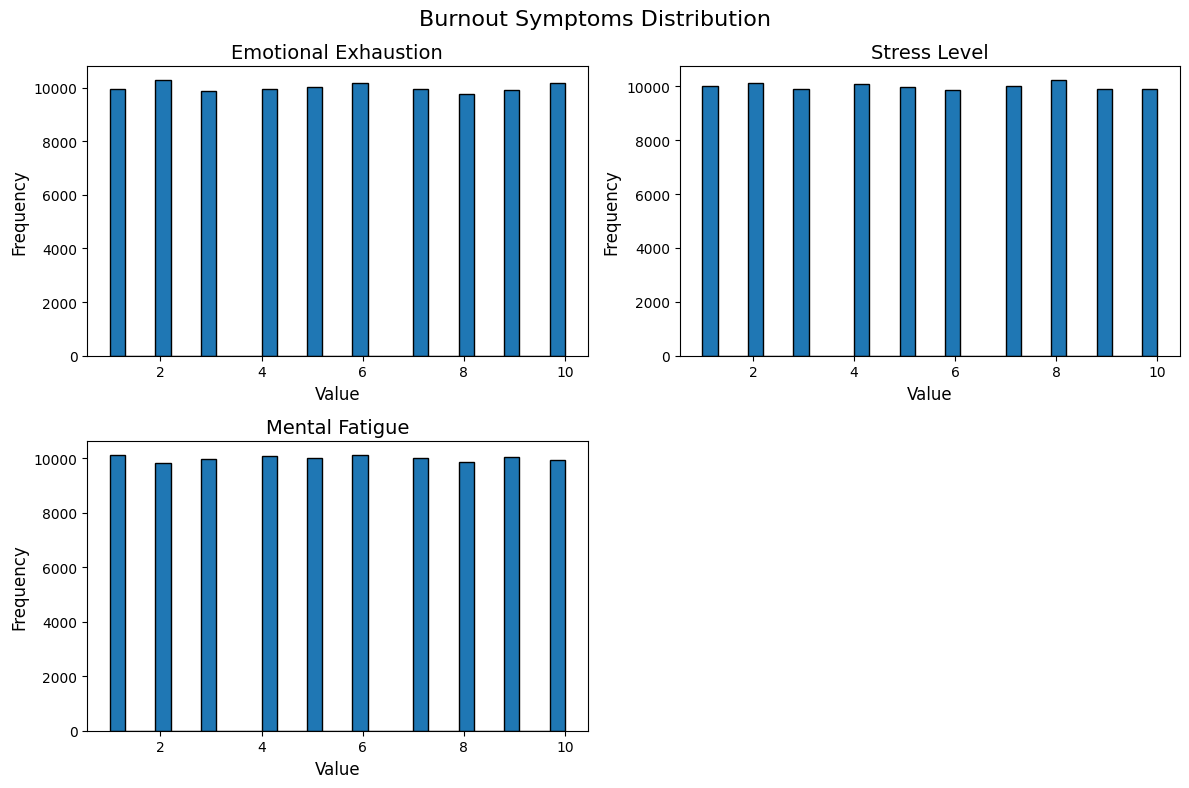

In [19]:
# Kiểm tra hàm Histogram

plot_distribution(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"],
    title="Burnout Symptoms Distribution"

)

### 2.5 Boxplot Function

Phần này xây dựng hàm trực quan hóa ngoại lệ (Outlier Analysis) bằng Boxplot cho một nhóm biến nghiên cứu. Hàm giúp quan sát nhanh phân bố dữ liệu và các giá trị ngoại lệ của từng biến.

In [20]:
# Xây dựng hàm vẽ Boxplot cho một nhóm biến

def plot_boxplots(dataframe, variables, title):

    total_variables = len(variables)

    rows = int(np.ceil(total_variables / 2))

    figure, axes = plt.subplots(

        nrows=rows,
        ncols=2,
        figsize=(12, 4 * rows)

    )

    axes = np.array(axes).reshape(-1)

    for axis, variable in zip(axes, variables):

        sample = dataframe[variable].dropna()

        if len(sample) > 100_000:

            sample = sample.sample(

                n=100_000,
                random_state=42

            )

        axis.boxplot(

            sample,
            vert=True,
            patch_artist=True

        )

        axis.set_title(

            variable.replace("_", " ").title()

        )

        axis.set_ylabel("Value")

    # Ẩn các ô không sử dụng

    for axis in axes[total_variables:]:

        axis.set_visible(False)

    figure.suptitle(

        title,
        fontsize=16

    )

    figure.tight_layout()

    plt.show()

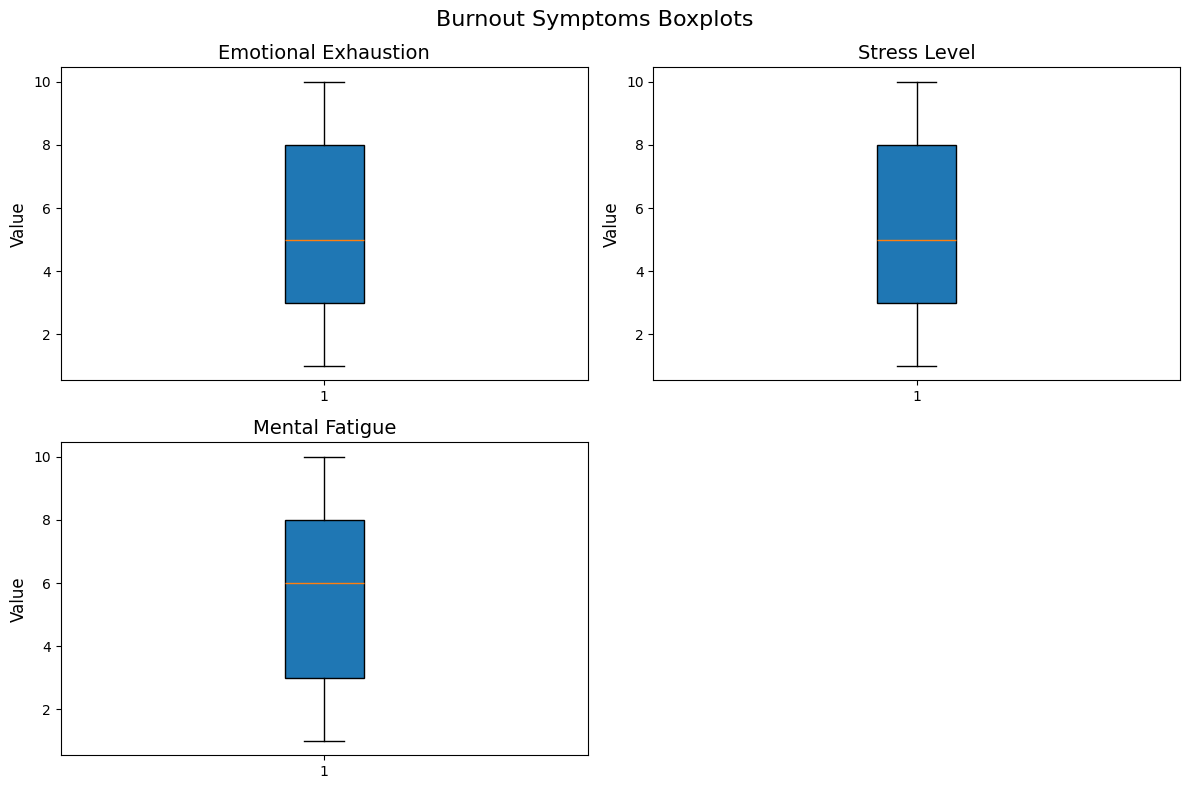

In [21]:
# Kiểm tra hàm Boxplot

plot_boxplots(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"],
    title="Burnout Symptoms Boxplots"

)

### 2.6 Correlation Function

Phần này xây dựng hàm tính toán và trực quan hóa ma trận tương quan giữa các biến trong một nhóm nghiên cứu bằng hệ số tương quan Pearson.

In [22]:
# Xây dựng hàm vẽ ma trận tương quan

def plot_correlation(dataframe, variables, title):

    correlation_matrix = dataframe[variables].corr(
        method=correlation_method
    )

    plt.figure(

        figsize=(8, 6)

    )

    sns.heatmap(

        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        square=True,
        linewidths=0.5

    )

    plt.title(title)

    plt.tight_layout()

    plt.show()

    return correlation_matrix

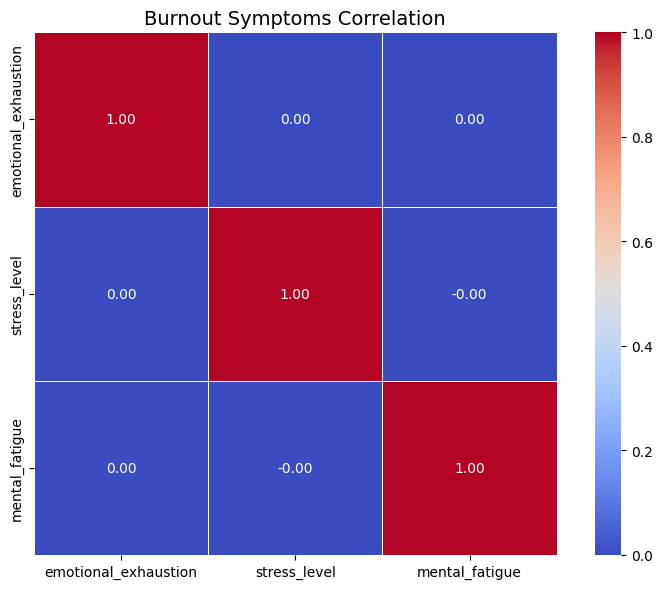

,emotional_exhaustion,stress_level,mental_fatigue
emotional_exhaustion,1.00,0.00,0.00
stress_level,0.00,1.00,-0.00
mental_fatigue,0.00,-0.00,1.00


In [23]:
# Kiểm tra hàm Correlation

plot_correlation(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"],
    title="Burnout Symptoms Correlation"

)

# 3. Dataset Overview

Phần này cung cấp cái nhìn tổng quan về bộ dữ liệu sau khi làm sạch, bao gồm cấu trúc dữ liệu, kiểu dữ liệu, phân bố các loại biến và thống kê mô tả cơ bản. Đây là bước nền tảng trước khi phân tích chi tiết từng nhóm biến nghiên cứu.

### 3.1 Dataset Structure

Kiểm tra kích thước và cấu trúc tổng thể của bộ dữ liệu.

In [24]:
# Hiển thị thông tin tổng quan của bộ dữ liệu

dataset_summary = pd.DataFrame({

    "Metric": [

        "Number of Samples",
        "Number of Variables",
        "Numerical Variables",
        "Categorical Variables"

    ],

    "Value": [

        len(df),
        df.shape[1],
        len(numerical_features),
        len(categorical_features)

    ]

})

display(dataset_summary)

,Metric,Value
0,Number of Samples,5000000
1,Number of Variables,35
2,Numerical Variables,29
3,Categorical Variables,6


### 3.2 Data Types

Kiểm tra kiểu dữ liệu của các biến nhằm đảm bảo dữ liệu phù hợp cho các phương pháp phân tích tiếp theo.

In [25]:
# Thống kê số lượng từng kiểu dữ liệu

data_types = (

    df.dtypes
    .astype(str)
    .value_counts()
    .reset_index()

)

data_types.columns = [

    "Data Type",
    "Count"

]

display(data_types)

,Data Type,Count
0,int64,21
1,float64,8
2,object,6


In [26]:
# Hiển thị danh sách kiểu dữ liệu của từng biến

variable_types = pd.DataFrame({

    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str)

})

display(variable_types)

,Variable,Data Type
user_id,user_id,int64
age,age,int64
occupation,occupation,object
work_mode,work_mode,object
device_usage_type,device_usage_type,object
daily_screen_time,daily_screen_time,float64
social_media_hours,social_media_hours,float64
doomscrolling_duration,doomscrolling_duration,float64
app_switch_frequency,app_switch_frequency,int64
notification_count,notification_count,int64


### 3.3 Descriptive Statistics

Tóm tắt các thống kê mô tả của toàn bộ biến số trong bộ dữ liệu.

In [27]:
# Thống kê mô tả các biến số

overall_statistics = summarize_variables(

    dataframe=df,
    variables=numerical_features

)

display(overall_statistics)

,Mean,Median,Standard Deviation,Minimum,Maximum
user_id,2500000.50,2500000.50,1443375.82,1.00,5000000.00
age,38.50,38.00,12.12,18.00,59.00
daily_screen_time,8.00,8.00,2.49,1.00,18.00
social_media_hours,3.52,3.50,1.74,0.00,12.00
doomscrolling_duration,1.83,1.80,1.13,0.00,7.90
app_switch_frequency,129.50,129.00,69.28,10.00,249.00
notification_count,209.44,209.00,109.66,20.00,399.00
smartphone_unlocks,157.04,157.00,82.28,15.00,299.00
late_night_device_usage,0.65,1.00,0.48,0.00,1.00
focus_sessions,4.50,5.00,2.87,0.00,9.00


# 4. Burnout Construct Analysis

Phần này phân tích các nhóm biến thuộc khung Digital Burnout Indicator (DBI) nhằm khám phá đặc điểm phân bố dữ liệu, thống kê mô tả, giá trị ngoại lệ và mối quan hệ giữa các biến trong từng nhóm nghiên cứu.

Kết quả phân tích sẽ giúp hiểu rõ đặc điểm của từng cấu phần Digital Burnout và cung cấp cơ sở cho quá trình Feature Validation và xây dựng mô hình Machine Learning ở các notebook tiếp theo.

# 4.1 Burnout Symptoms

Phần này phân tích nhóm biến Burnout Symptoms nhằm khám phá đặc điểm phân bố, thống kê mô tả, giá trị ngoại lệ và mối tương quan giữa các biến trong nhóm.

#### 4.1.1 Descriptive Statistics

Thống kê mô tả được sử dụng để tóm tắt xu hướng trung tâm và mức độ phân tán của các biến trong nhóm Burnout Symptoms.

In [28]:
# Thống kê mô tả nhóm Burnout Symptoms

burnout_summary = summarize_variables(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"]

)

display(
    burnout_summary
)

,Mean,Median,Standard Deviation,Minimum,Maximum
emotional_exhaustion,5.50,6.00,2.87,1,10
stress_level,5.50,5.00,2.87,1,10
mental_fatigue,5.50,5.00,2.87,1,10


#### 4.1.2 Distribution Analysis

Histogram được sử dụng để quan sát hình dạng phân bố của từng biến trong nhóm Burnout Symptoms.

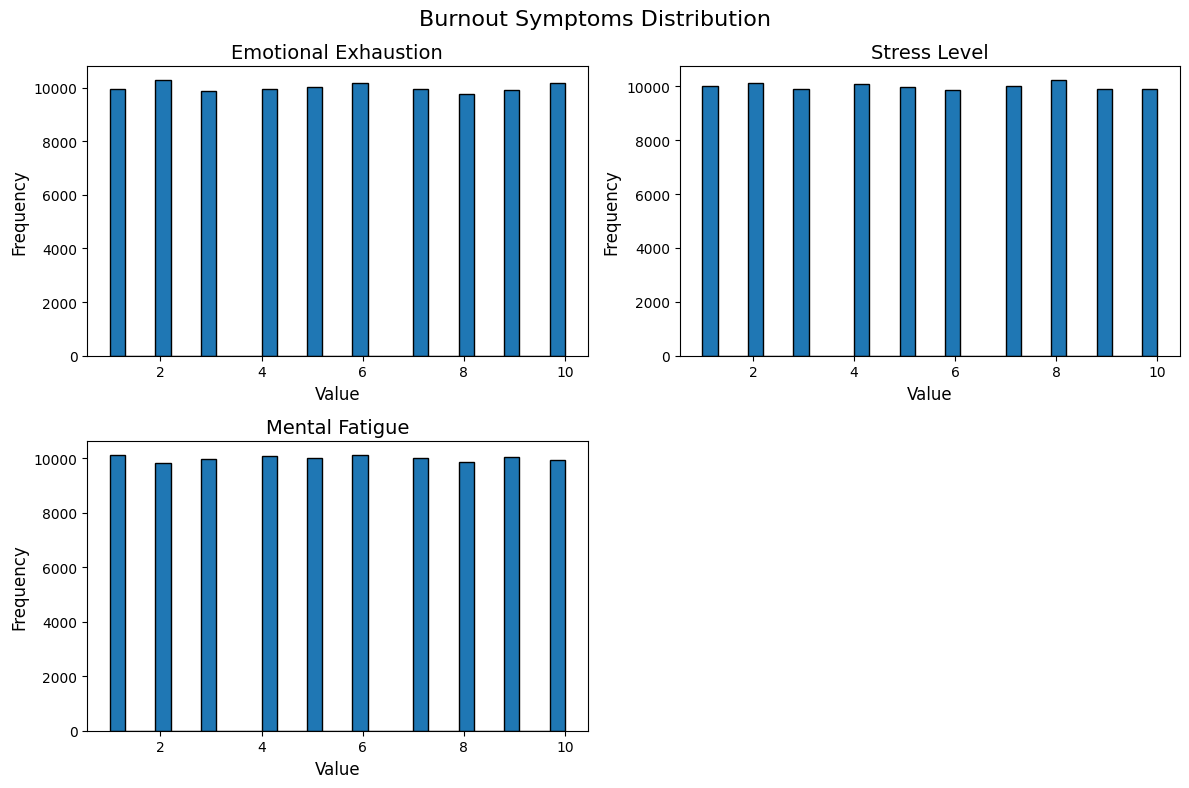

In [29]:
# Phân bố dữ liệu nhóm Burnout Symptoms

plot_distribution(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"],
    title="Burnout Symptoms Distribution"

)

#### 4.1.3 Outlier Analysis

Boxplot được sử dụng để quan sát phạm vi phân bố và xác định các giá trị ngoại lệ của từng biến.

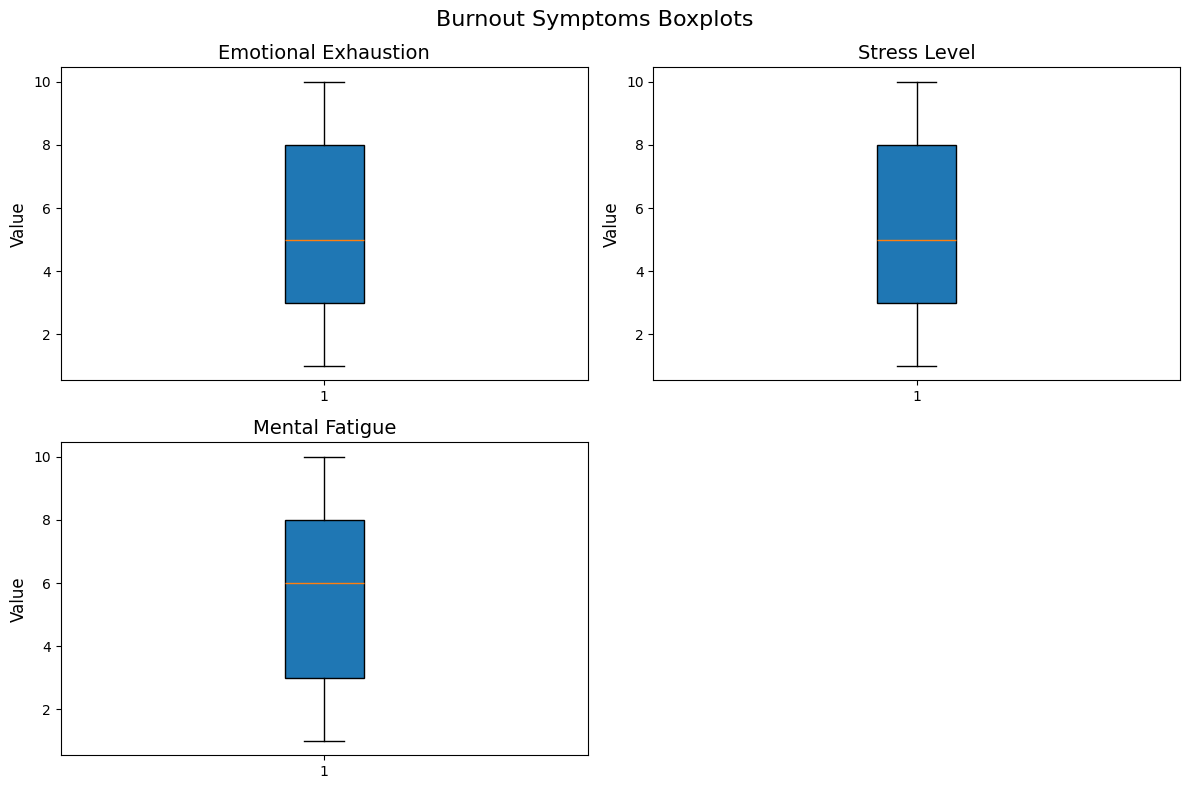

In [30]:
# Phân tích ngoại lệ nhóm Burnout Symptoms

plot_boxplots(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"],
    title="Burnout Symptoms Boxplots"

)

#### 4.1.4 Correlation Analysis

Ma trận tương quan Pearson được sử dụng để đánh giá mối quan hệ tuyến tính giữa các biến trong nhóm Burnout Symptoms.

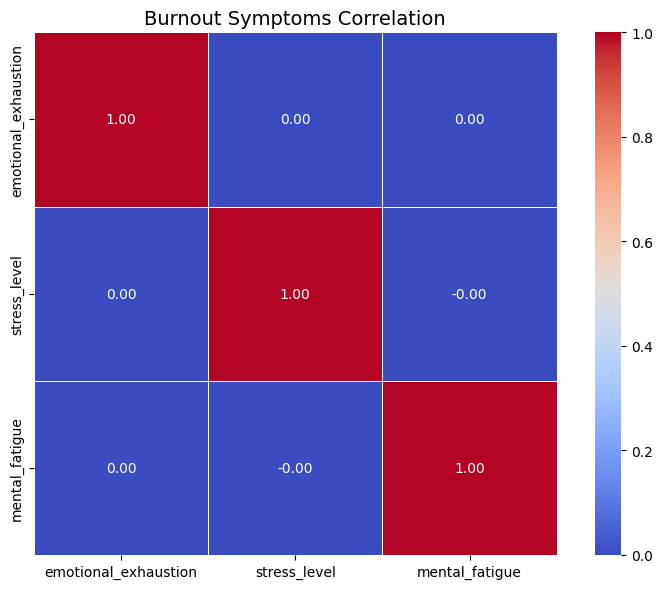

,emotional_exhaustion,stress_level,mental_fatigue
emotional_exhaustion,1.00,0.00,0.00
stress_level,0.00,1.00,-0.00
mental_fatigue,0.00,-0.00,1.00


In [31]:
# Ma trận tương quan nhóm Burnout Symptoms

burnout_correlation = plot_correlation(

    dataframe=df,
    variables=construct_groups["Burnout Symptoms"],
    title="Burnout Symptoms Correlation"

)

display(
    burnout_correlation
)

In [32]:
df[
    construct_groups["Burnout Symptoms"]
].describe()

,emotional_exhaustion,stress_level,mental_fatigue
count,5000000.00,5000000.00,5000000.00
mean,5.50,5.50,5.50
std,2.87,2.87,2.87
min,1.00,1.00,1.00
25%,3.00,3.00,3.00
50%,6.00,5.00,5.00
75%,8.00,8.00,8.00
max,10.00,10.00,10.00


# 4.2 Digital Exposure

Phần này phân tích nhóm biến Digital Exposure nhằm khám phá đặc điểm phân bố dữ liệu, thống kê mô tả, giá trị ngoại lệ và mối tương quan giữa các biến trong nhóm.

#### 4.2.1 Descriptive Statistics

Thống kê mô tả được sử dụng để tóm tắt xu hướng trung tâm và mức độ phân tán của các biến trong nhóm Digital Exposure.

In [33]:
# Thống kê mô tả nhóm Digital Exposure

digital_exposure_summary = summarize_variables(

    dataframe=df,
    variables=construct_groups["Digital Exposure"]

)

display(
    digital_exposure_summary
)

,Mean,Median,Standard Deviation,Minimum,Maximum
daily_screen_time,8.00,8.00,2.49,1.00,18.00
social_media_hours,3.52,3.50,1.74,0.00,12.00
doomscrolling_duration,1.83,1.80,1.13,0.00,7.90
late_night_device_usage,0.65,1.00,0.48,0.00,1.00
notification_count,209.44,209.00,109.66,20.00,399.00
smartphone_unlocks,157.04,157.00,82.28,15.00,299.00
app_switch_frequency,129.50,129.00,69.28,10.00,249.00


#### 4.2.2 Distribution Analysis

Histogram được sử dụng để quan sát phân bố dữ liệu của từng biến trong nhóm Digital Exposure.

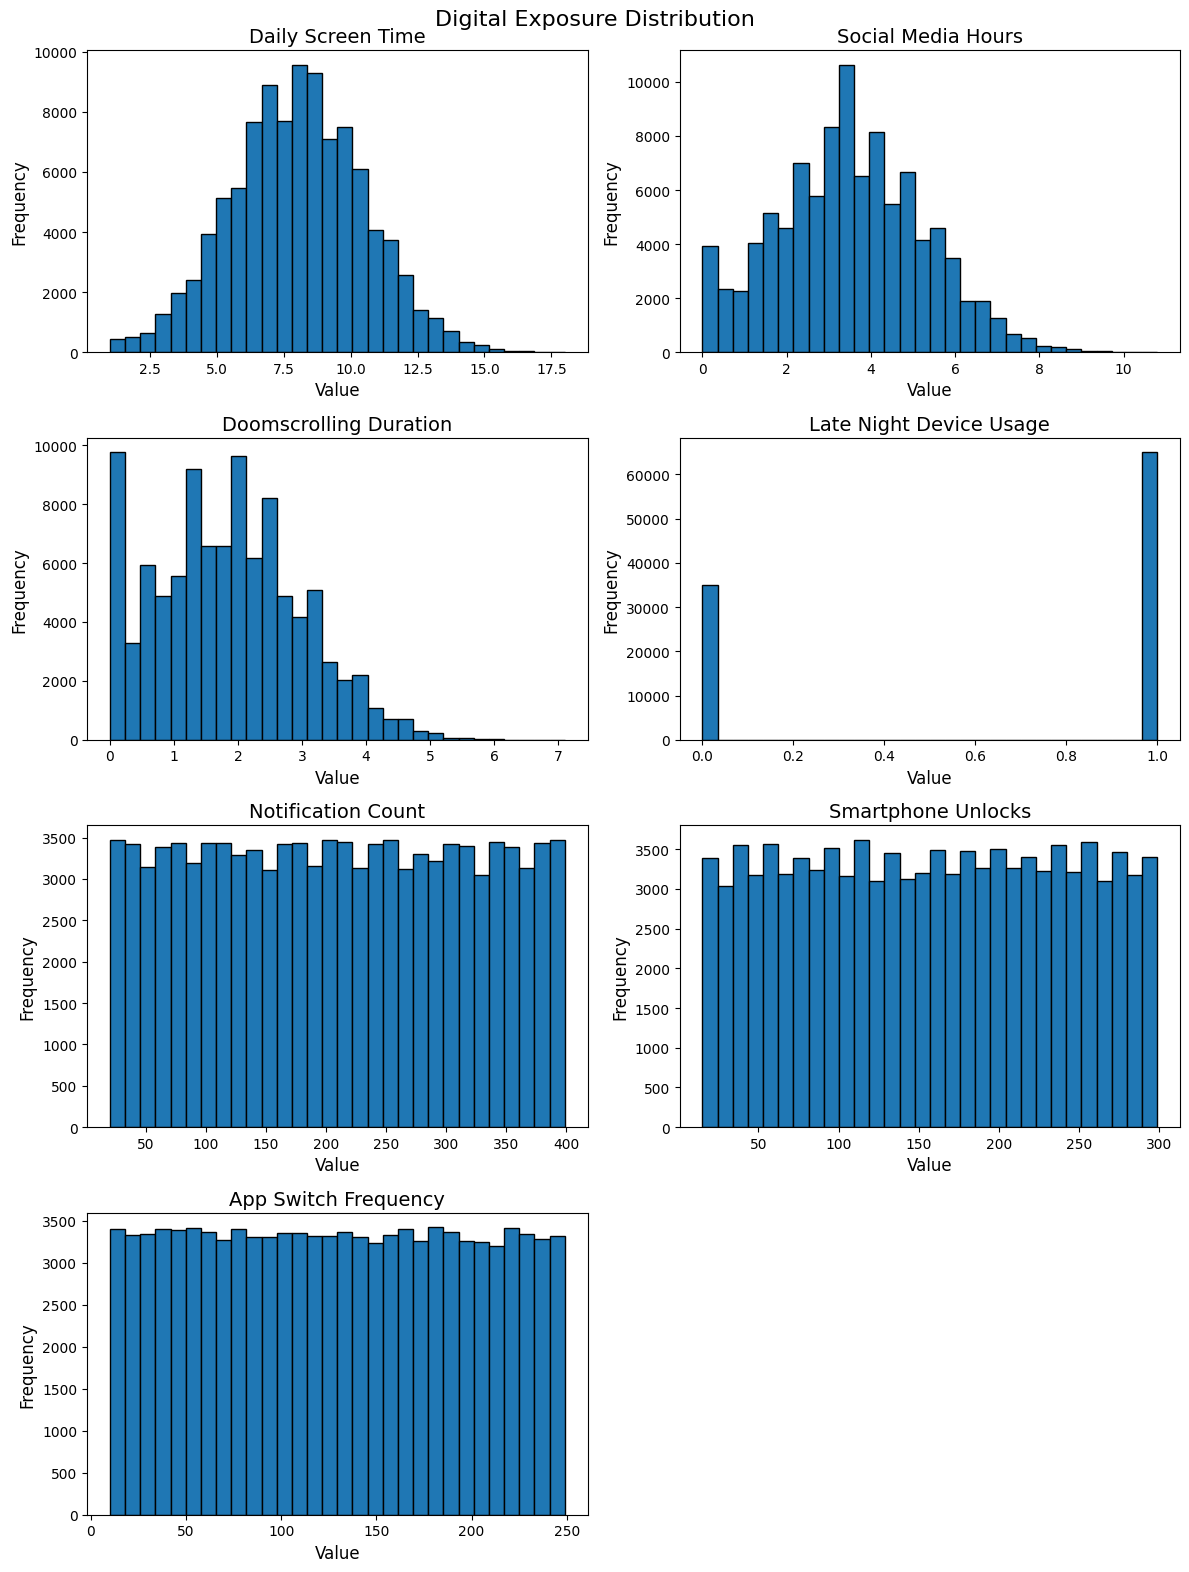

In [34]:
# Phân bố dữ liệu nhóm Digital Exposure

plot_distribution(

    dataframe=df,
    variables=construct_groups["Digital Exposure"],
    title="Digital Exposure Distribution"

)

#### 4.2.3 Outlier Analysis

Boxplot được sử dụng để quan sát phạm vi phân bố và xác định các giá trị ngoại lệ của từng biến trong nhóm Digital Exposure.

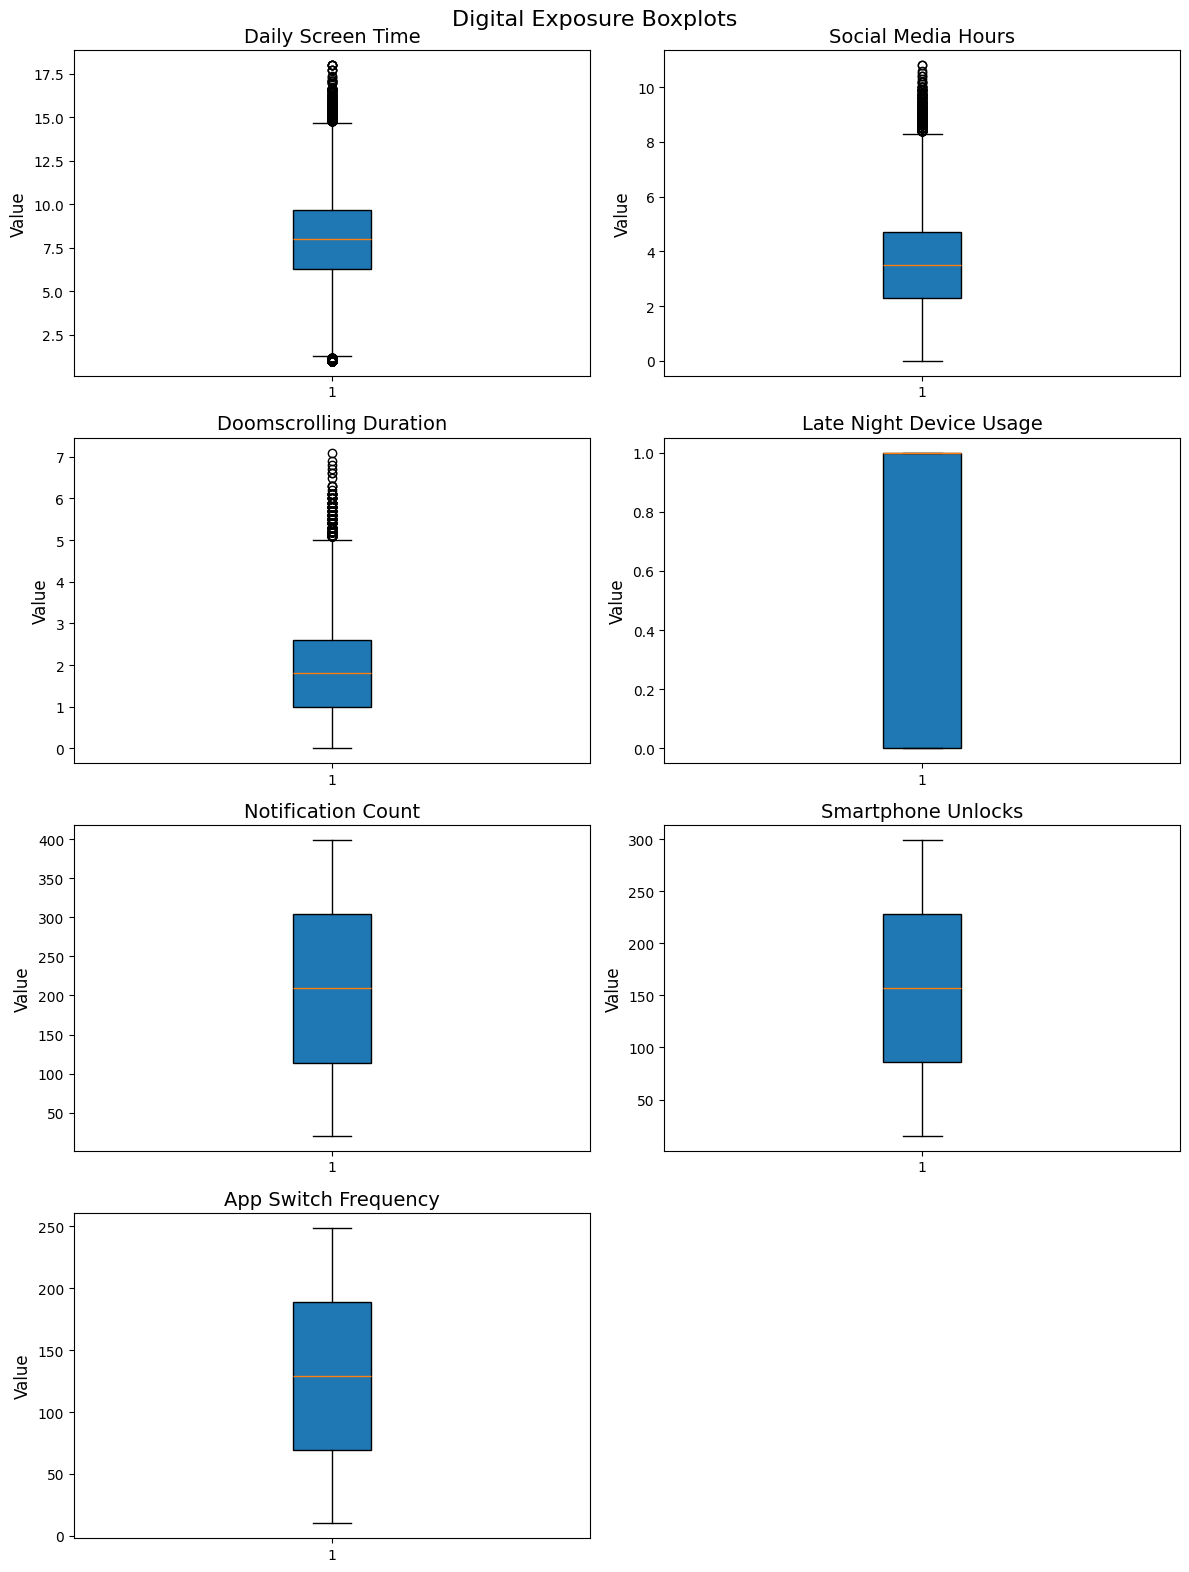

In [35]:
# Phân tích ngoại lệ nhóm Digital Exposure

plot_boxplots(

    dataframe=df,
    variables=construct_groups["Digital Exposure"],
    title="Digital Exposure Boxplots"

)

#### 4.2.4 Correlation Analysis

Ma trận tương quan Pearson được sử dụng để đánh giá mối quan hệ tuyến tính giữa các biến trong nhóm Digital Exposure.

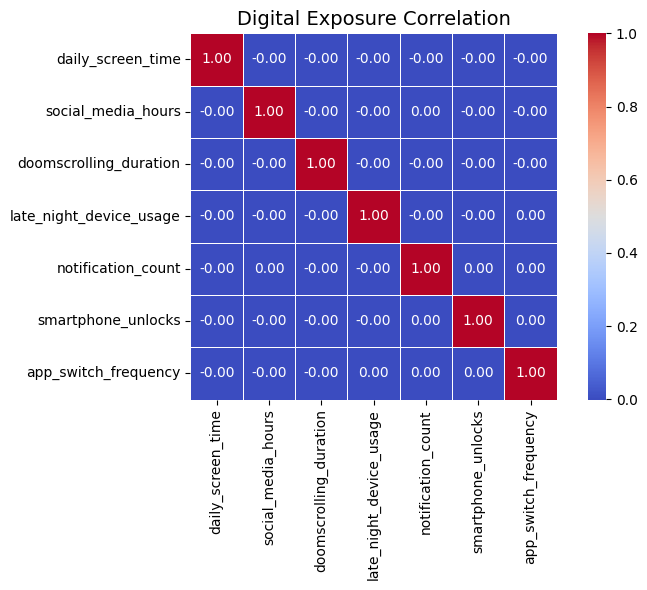

,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency
daily_screen_time,1.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00
social_media_hours,-0.00,1.00,-0.00,-0.00,0.00,-0.00,-0.00
doomscrolling_duration,-0.00,-0.00,1.00,-0.00,-0.00,-0.00,-0.00
late_night_device_usage,-0.00,-0.00,-0.00,1.00,-0.00,-0.00,0.00
notification_count,-0.00,0.00,-0.00,-0.00,1.00,0.00,0.00
smartphone_unlocks,-0.00,-0.00,-0.00,-0.00,0.00,1.00,0.00
app_switch_frequency,-0.00,-0.00,-0.00,0.00,0.00,0.00,1.00


In [36]:
# Ma trận tương quan nhóm Digital Exposure

digital_exposure_correlation = plot_correlation(

    dataframe=df,
    variables=construct_groups["Digital Exposure"],
    title="Digital Exposure Correlation"

)

display(
    digital_exposure_correlation
)

# 4.3 Cognitive Performance

Phần này phân tích nhóm biến Cognitive Performance nhằm khám phá đặc điểm phân bố dữ liệu, thống kê mô tả, giá trị ngoại lệ và mối tương quan giữa các biến trong nhóm. Kết quả giúp đánh giá đặc điểm của các chỉ số phản ánh hiệu suất nhận thức trong bối cảnh Digital Burnout.

#### 4.3.1 Descriptive Statistics

Thống kê mô tả được sử dụng để tóm tắt xu hướng trung tâm và mức độ phân tán của các biến trong nhóm Cognitive Performance.

In [37]:
# Thống kê mô tả nhóm Cognitive Performance

cognitive_summary = summarize_variables(

    dataframe=df,
    variables=construct_groups["Cognitive Performance"]

)

display(
    cognitive_summary
)

,Mean,Median,Standard Deviation,Minimum,Maximum
concentration_score,5.50,6.00,2.87,1.00,10.00
distraction_frequency,60.03,60.00,34.35,1.00,119.00
focus_sessions,4.50,5.00,2.87,0.00,9.00
deep_work_hours,3.03,3.00,1.71,0.00,11.80
task_completion_rate,70.00,70.00,17.60,40.00,100.00
motivation_level,5.49,5.00,2.84,1.00,10.00


#### 4.3.2 Distribution Analysis

Histogram được sử dụng để quan sát phân bố dữ liệu của từng biến trong nhóm Cognitive Performance.

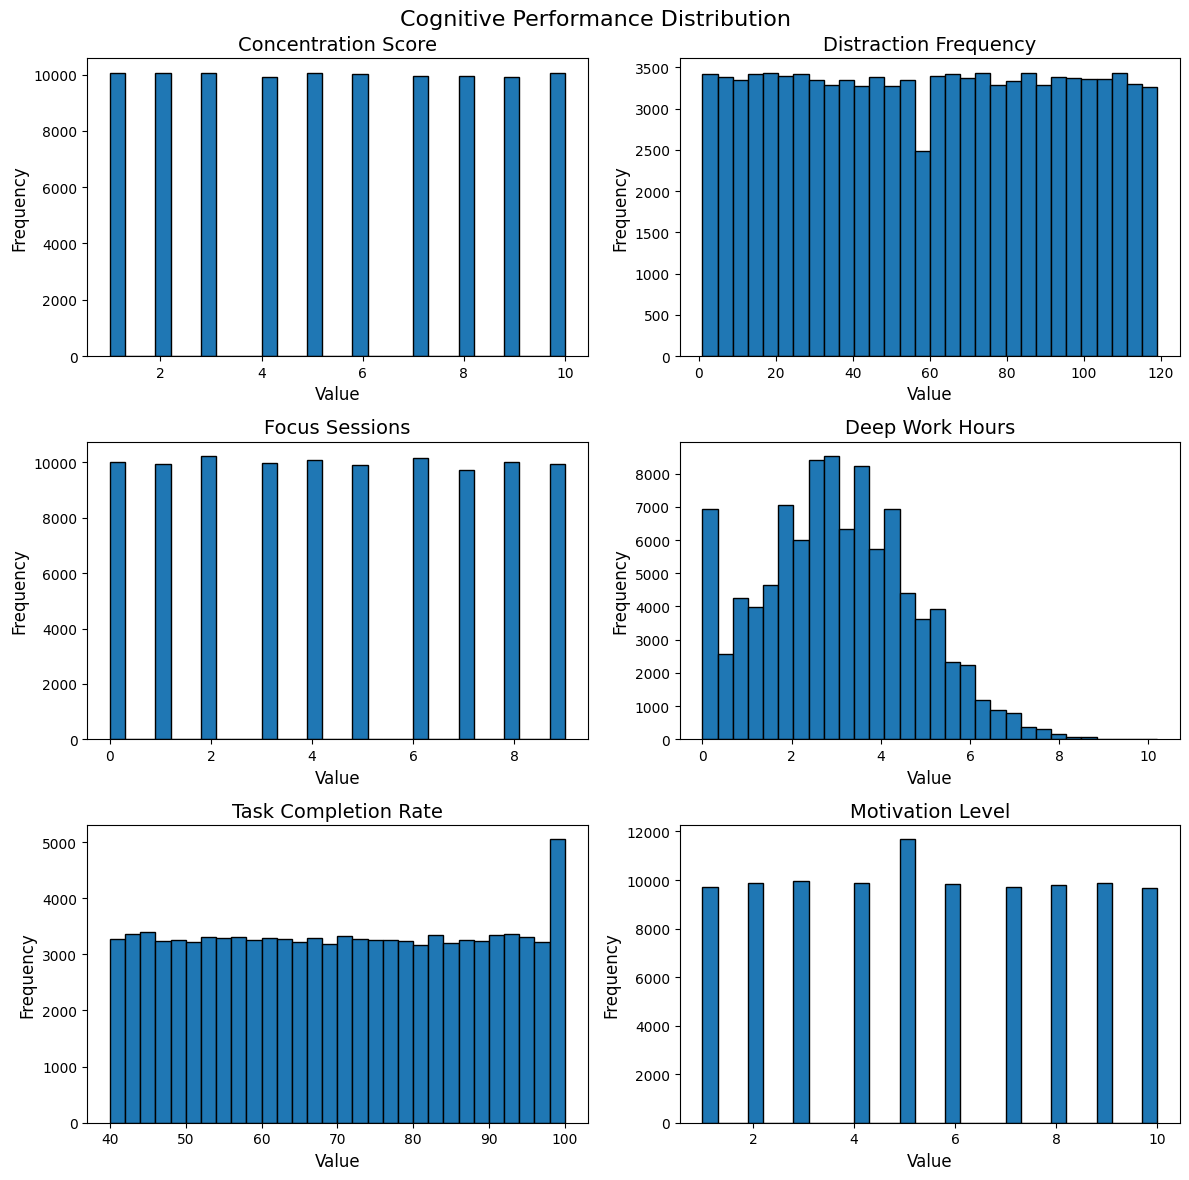

In [38]:
# Phân bố dữ liệu nhóm Cognitive Performance

plot_distribution(

    dataframe=df,
    variables=construct_groups["Cognitive Performance"],
    title="Cognitive Performance Distribution"

)

#### 4.3.3 Outlier Analysis

Boxplot được sử dụng để quan sát phạm vi phân bố và xác định các giá trị ngoại lệ của từng biến trong nhóm Cognitive Performance.

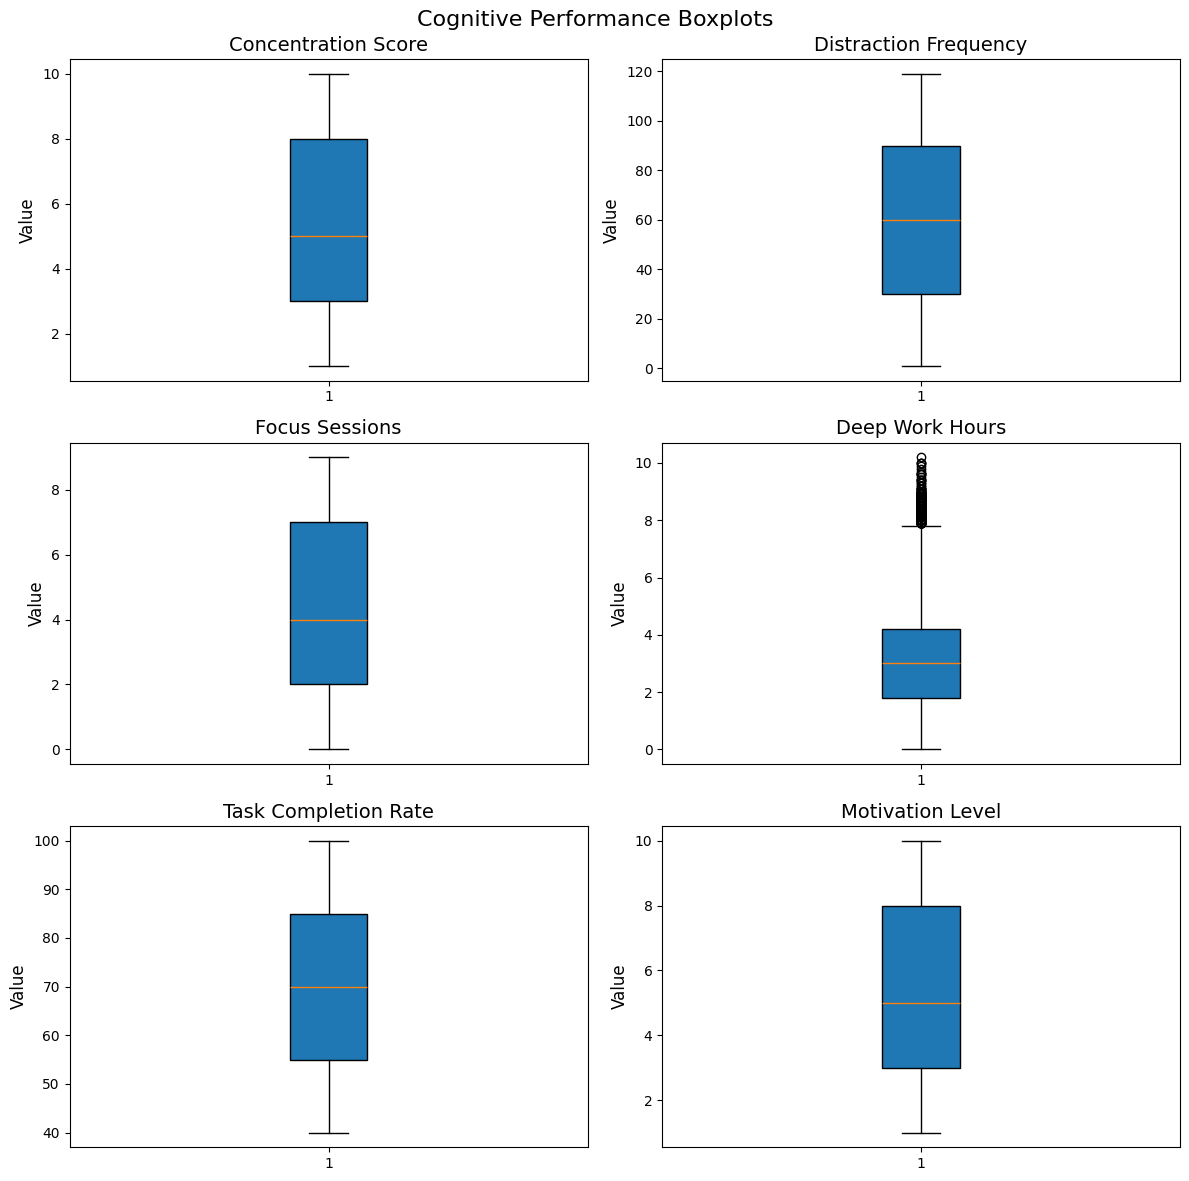

In [39]:
# Phân tích ngoại lệ nhóm Cognitive Performance

plot_boxplots(

    dataframe=df,
    variables=construct_groups["Cognitive Performance"],
    title="Cognitive Performance Boxplots"

)

#### 4.3.4 Correlation Analysis

Ma trận tương quan Pearson được sử dụng để đánh giá mối quan hệ tuyến tính giữa các biến trong nhóm Cognitive Performance.

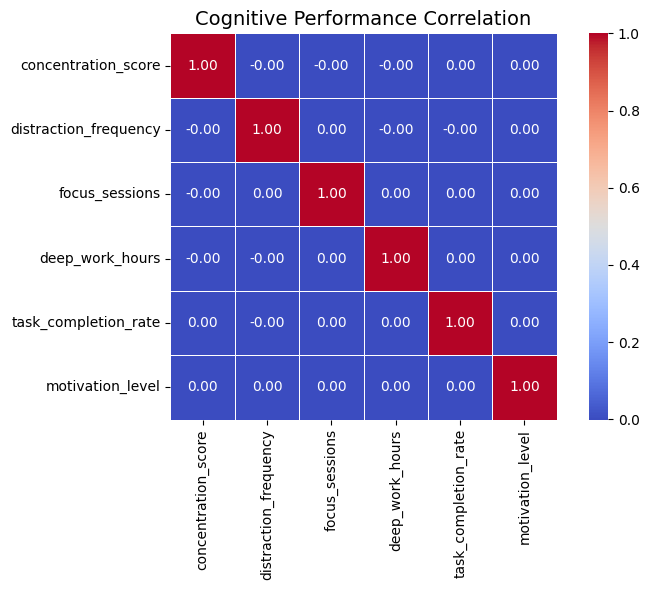

,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,motivation_level
concentration_score,1.00,-0.00,-0.00,-0.00,0.00,0.00
distraction_frequency,-0.00,1.00,0.00,-0.00,-0.00,0.00
focus_sessions,-0.00,0.00,1.00,0.00,0.00,0.00
deep_work_hours,-0.00,-0.00,0.00,1.00,0.00,0.00
task_completion_rate,0.00,-0.00,0.00,0.00,1.00,0.00
motivation_level,0.00,0.00,0.00,0.00,0.00,1.00


In [40]:
# Ma trận tương quan nhóm Cognitive Performance

cognitive_correlation = plot_correlation(

    dataframe=df,
    variables=construct_groups["Cognitive Performance"],
    title="Cognitive Performance Correlation"

)

display(
    cognitive_correlation
)

# 4.4 Sleep & Recovery

Phần này phân tích nhóm biến Sleep & Recovery nhằm khám phá đặc điểm phân bố dữ liệu, thống kê mô tả, giá trị ngoại lệ và mối tương quan giữa các biến trong nhóm. Kết quả giúp đánh giá đặc điểm của các yếu tố liên quan đến giấc ngủ và khả năng phục hồi trong bối cảnh Digital Burnout.

#### 4.4.1 Descriptive Statistics

Thống kê mô tả được sử dụng để tóm tắt xu hướng trung tâm và mức độ phân tán của các biến trong nhóm Sleep & Recovery.

In [41]:
# Thống kê mô tả nhóm Sleep & Recovery

sleep_summary = summarize_variables(

    dataframe=df,
    variables=construct_groups["Sleep & Recovery"]

)

display(
    sleep_summary
)

,Mean,Median,Standard Deviation,Minimum,Maximum
sleep_hours,6.50,6.50,1.46,3.00,10.00
sleep_quality,5.50,6.00,2.87,1.00,10.00


#### 4.4.2 Distribution Analysis

Histogram được sử dụng để quan sát phân bố dữ liệu của từng biến trong nhóm Sleep & Recovery.

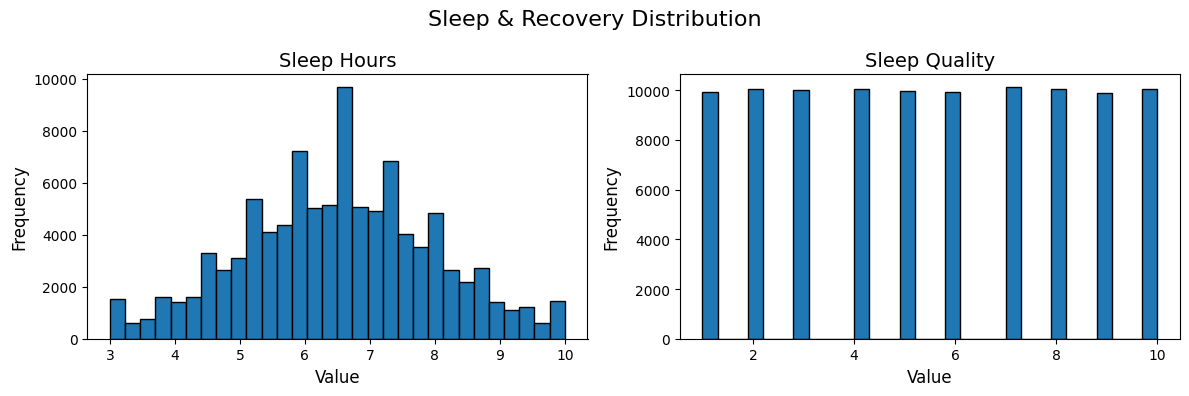

In [42]:
# Phân bố dữ liệu nhóm Sleep & Recovery

plot_distribution(

    dataframe=df,
    variables=construct_groups["Sleep & Recovery"],
    title="Sleep & Recovery Distribution"

)

#### 4.4.3 Outlier Analysis

Boxplot được sử dụng để quan sát phạm vi phân bố và xác định các giá trị ngoại lệ của từng biến trong nhóm Sleep & Recovery.

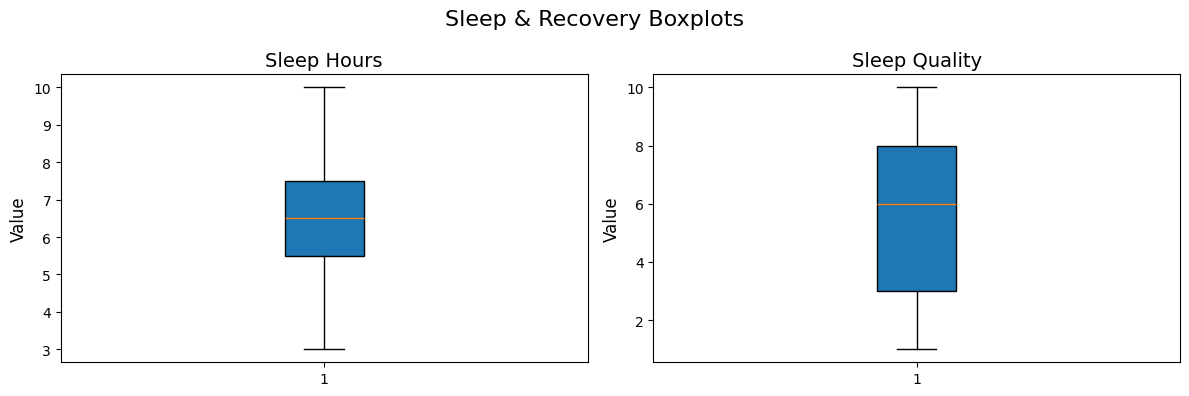

In [43]:
# Phân tích ngoại lệ nhóm Sleep & Recovery

plot_boxplots(

    dataframe=df,
    variables=construct_groups["Sleep & Recovery"],
    title="Sleep & Recovery Boxplots"

)

#### 4.4.4 Correlation Analysis

Ma trận tương quan Pearson được sử dụng để đánh giá mối quan hệ tuyến tính giữa các biến trong nhóm Sleep & Recovery.

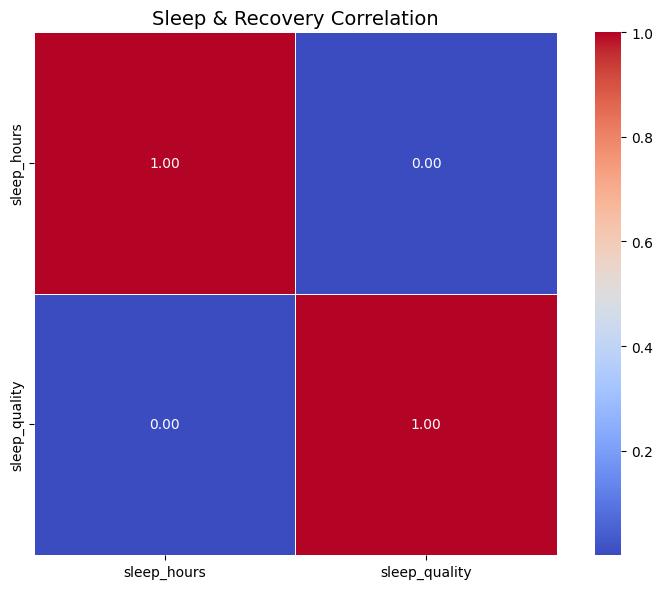

,sleep_hours,sleep_quality
sleep_hours,1.00,0.00
sleep_quality,0.00,1.00


In [44]:
# Ma trận tương quan nhóm Sleep & Recovery

sleep_correlation = plot_correlation(

    dataframe=df,
    variables=construct_groups["Sleep & Recovery"],
    title="Sleep & Recovery Correlation"

)

display(
    sleep_correlation
)

# 4.5 Context Variables

Phần này phân tích các biến ngữ cảnh nhằm khám phá đặc điểm phân bố của từng nhóm dữ liệu và tỷ lệ xuất hiện của các danh mục trong bộ dữ liệu. Do đây là các biến phân loại, việc phân tích tập trung vào tần suất và phân bố thay vì thống kê mô tả hoặc tương quan.

#### 4.5.1 Frequency Distribution

Thống kê tần suất và tỷ lệ phần trăm được sử dụng để mô tả phân bố của từng biến phân loại trong nhóm Context Variables.

In [45]:
# Thống kê tần suất các biến Context Variables

for variable in construct_groups["Context Variables"]:

    print(f"\n{variable}")

    frequency_table = (

        df[variable]
        .value_counts(dropna=False)
        .rename("Frequency")
        .to_frame()

    )

    frequency_table["Percentage"] = (

        frequency_table["Frequency"]

        / len(df)

        * 100

    ).round(2)

    display(
        frequency_table
    )


work_mode


,Frequency,Percentage
work_mode,,
Remote,2250774,45.02
Hybrid,1748165,34.96
Office,1001061,20.02



device_usage_type


,Frequency,Percentage
device_usage_type,,
Balanced,1749883,35.00
Work-Centric,1749379,34.99
Entertainment-Centric,1500738,30.01


#### 4.5.2 Distribution Analysis

Biểu đồ cột được sử dụng để trực quan hóa phân bố của từng biến phân loại trong nhóm Context Variables.

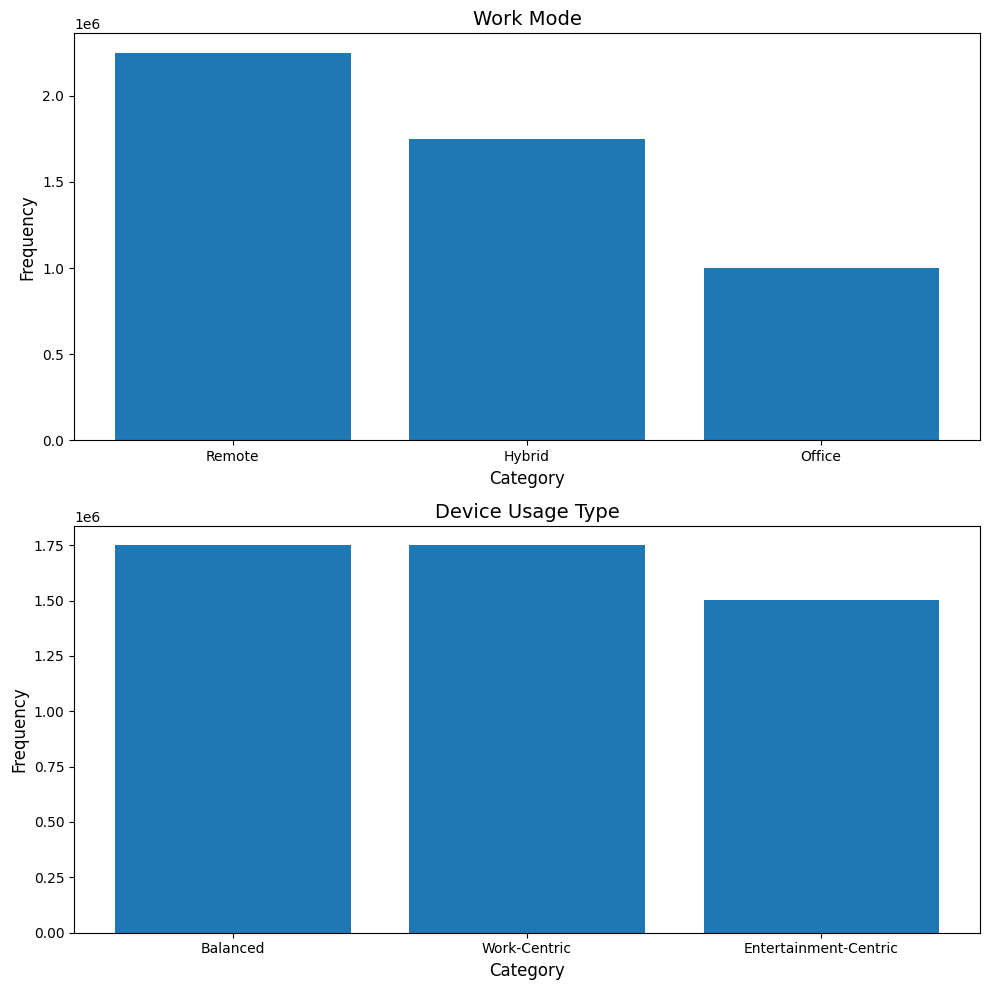

In [46]:
# Vẽ biểu đồ cột cho các biến Context Variables

rows = len(
    construct_groups["Context Variables"]
)

figure, axes = plt.subplots(

    nrows=rows,
    ncols=1,
    figsize=(10, 5 * rows)

)

if rows == 1:

    axes = [axes]

for axis, variable in zip(

    axes,
    construct_groups["Context Variables"]

):

    counts = (

        df[variable]
        .value_counts()

    )

    axis.bar(

        counts.index.astype(str),
        counts.values

    )

    axis.set_title(

        variable.replace("_", " ").title()

    )

    axis.set_xlabel("Category")

    axis.set_ylabel("Frequency")

plt.tight_layout()

plt.show()

# 5. EDA Findings Summary

Phần này tổng hợp các kết quả chính từ quá trình Exploratory Data Analysis (EDA), bao gồm đặc điểm phân bố dữ liệu, sự xuất hiện của giá trị ngoại lệ và mối quan hệ giữa các nhóm biến. Kết quả đóng vai trò là cơ sở cho quá trình Feature Validation và xây dựng mô hình Machine Learning trong notebook tiếp theo.

### 5.1 EDA Summary Table

Bảng dưới đây tổng hợp các đặc điểm chính của từng nhóm biến sau quá trình EDA.

In [47]:
# Tổng hợp kết quả EDA

eda_summary = pd.DataFrame({

    "Construct": [

        "Burnout Symptoms",
        "Digital Exposure",
        "Cognitive Performance",
        "Sleep & Recovery",
        "Context Variables"

    ],

    "Distribution": [

        "Approximately Uniform",
        "Approximately Uniform",
        "Approximately Uniform",
        "Approximately Uniform",
        "Categorical Distribution"

    ],

    "Outliers": [

        "Observed",
        "Observed",
        "Observed",
        "Observed",
        "Not Applicable"

    ],

    "Correlation": [

        "Weak",
        "Weak",
        "Weak",
        "Weak",
        "Not Applicable"

    ],

    "EDA Decision": [

        "Proceed to Feature Validation",
        "Proceed to Feature Validation",
        "Proceed to Feature Validation",
        "Proceed to Feature Validation",
        "Proceed to Feature Validation"

    ]

})

display(
    eda_summary
)

,Construct,Distribution,Outliers,Correlation,EDA Decision
0,Burnout Symptoms,Approximately Uniform,Observed,Weak,Proceed to Feature Validation
1,Digital Exposure,Approximately Uniform,Observed,Weak,Proceed to Feature Validation
2,Cognitive Performance,Approximately Uniform,Observed,Weak,Proceed to Feature Validation
3,Sleep & Recovery,Approximately Uniform,Observed,Weak,Proceed to Feature Validation
4,Context Variables,Categorical Distribution,Not Applicable,Not Applicable,Proceed to Feature Validation


# 6. Save EDA Outputs

Phần này lưu các kết quả tổng hợp từ quá trình Exploratory Data Analysis (EDA), bao gồm bảng tóm tắt thống kê và kết quả tổng hợp EDA. Các tệp đầu ra sẽ được sử dụng làm tài liệu tham khảo cho quá trình Feature Validation và báo cáo nghiên cứu.

In [48]:
# Tạo thư mục lưu kết quả EDA

output_directory = "../../outputs/international_dataset/eda"

os.makedirs(

    output_directory,

    exist_ok=True

)

print(
    "Output directory created successfully."
)

Output directory created successfully.


In [49]:
# Lưu bảng tổng hợp EDA

eda_summary.to_csv(

    os.path.join(

        output_directory,

        "eda_summary.csv"

    ),

    index=False

)